# Predicting Machine Failure (Predictive Maintenance)

**The problem, in plain English**
A plant (like a refinery) runs hundreds of pumps and compressors. If one breaks unexpectedly, it means downtime and a lot of money lost. If we can *predict* which machines are about to fail from their sensor readings, maintenance teams can fix them **before** they break.

**What I do in this notebook**
1. Load sensor data  →  2. Explore it  →  3. Split into train / test  →  4. Train two models  →  5. Measure them (accuracy, precision, recall, F1, confusion matrix)  →  6. See which sensors matter most

This is a **binary classification** problem: the answer is either `1` (will fail) or `0` (won't fail).

> **Note on data:** I use the public **AI4I 2020 Predictive Maintenance** dataset from the UCI repository (10,000 machines, 339 failures). It is a **synthetic** dataset created by its authors to reflect real industrial maintenance data, so it is great for learning, but results should not be read as performance on real plant data.

## Step 1 — Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

## Step 2 — Load the data

Each row is one machine. The columns I use as inputs are the five sensor readings, and `Machine failure` is what we want to predict.

| Column | Meaning |
|---|---|
| `Air temperature [K]` | Ambient temperature |
| `Process temperature [K]` | Temperature of the process |
| `Rotational speed [rpm]` | Rotation speed |
| `Torque [Nm]` | Load on the machine |
| `Tool wear [min]` | Minutes of tool wear |
| `Machine failure` | **Target** — 1 = failed, 0 = ok |

**Columns I do *not* use:** `UDI` (row id, used as the index), `Product ID`, `Type`, and the five **failure-mode columns** (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`). The failure-mode columns *define* the target (a machine "fails" when any of them is 1), so using them as inputs would be cheating — this is called **data leakage**.

In [2]:
import os
# Works in Google Colab (/content) and locally (same folder as the notebook)
path = next(p for p in ["ai4i2020.csv", "/content/ai4i2020.csv"] if os.path.exists(p))
df = pd.read_csv(path, index_col=0)
print("Rows, columns:", df.shape)
display(df.head())

Rows, columns: (10000, 13)


,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,,,,,,,,,,,,,
1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Step 3 — Explore the data

In [3]:
print(df.isna().sum().sum(), "missing values")
df.describe().round(2)

0 missing values


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


### How many machines actually fail?
This matters a lot. If failures are rare, a model can look "accurate" while being useless.

Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.4%


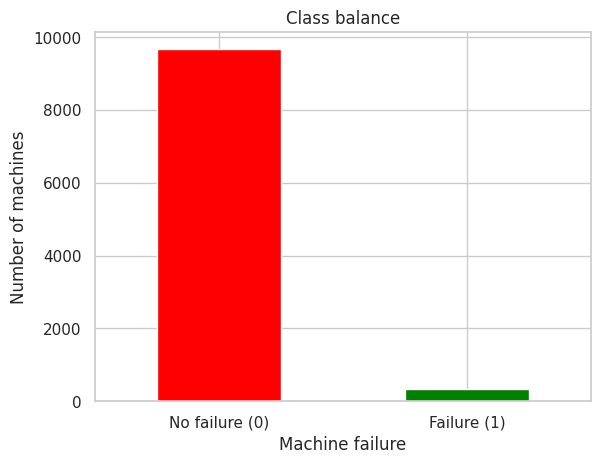

In [4]:
counts = df["Machine failure"].value_counts()
print(counts)
print(f"\nFailure rate: {df['Machine failure'].mean():.1%}")

counts.plot(kind="bar", color=["red", "green"])
plt.xticks([0, 1], ["No failure (0)", "Failure (1)"], rotation=0)
plt.title("Class balance"); plt.ylabel("Number of machines"); plt.show()

**Takeaway:** only about **3.4%** of machines fail (339 out of 10,000). This is called an *imbalanced* dataset. A lazy model that always says "no failure" would be ~97% accurate but would catch **zero** failures. So accuracy alone can't be trusted here.

### Do failed machines look different?

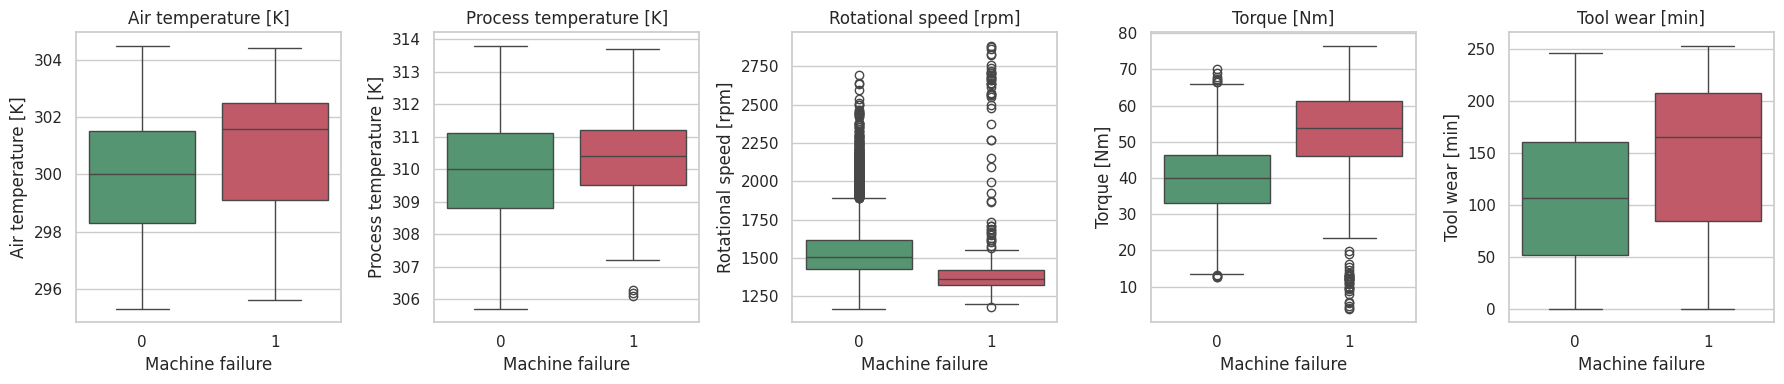

In [5]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, features):
    sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette=["#4C9F70", "#D1495B"])
    ax.set_title(col)
plt.tight_layout(); plt.show()

**Takeaway:** failed machines (right box in each plot) tend to have **higher torque**, **lower rotation speed** and **more tool wear** than healthy ones (median torque 54 vs 40 Nm; median rpm 1365 vs 1507). Air temperature is also slightly higher for failures, while process temperature barely differs. The model's job is to learn this pattern automatically.

## Step 4 — Split into training and test data

- **Training set (80%)** — the model learns from this.
- **Test set (20%)** — hidden from the model; used only at the end to check how it does on machines it has *never seen*.

`stratify=y` keeps the same failure % in both sets, which is important when failures are rare.

In [6]:
X = df[features]
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Training machines:", len(X_train), "| failure rate:", round(y_train.mean(), 3))
print("Test machines    :", len(X_test),  "| failure rate:", round(y_test.mean(), 3))

Training machines: 8000 | failure rate: 0.034
Test machines    : 2000 | failure rate: 0.034


## Step 5 — Train two models

1. **Logistic Regression** — a simple, easy-to-explain baseline.
2. **Random Forest** — many decision trees voting together; handles more complex patterns.

Because failures are rare, I use `class_weight="balanced"` so the model pays extra attention to the failure cases instead of ignoring them.

In [7]:
# Logistic Regression needs features on the same scale, so we scale first
log_reg = make_pipeline(StandardScaler(),
                        LogisticRegression(class_weight="balanced", max_iter=1000))
log_reg.fit(X_train, y_train)

rand_forest = RandomForestClassifier(n_estimators=200, max_depth=6,
                                     class_weight="balanced", random_state=42)
rand_forest.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## Step 6 — Evaluate on the test set

| Metric | Question it answers |
|---|---|
| **Accuracy** | Out of all machines, how many did we classify correctly? |
| **Precision** | When we predict *failure*, how often are we right? (low precision = many false alarms) |
| **Recall** | Of all machines that *really* failed, how many did we catch? (low recall = missed failures) |
| **F1-score** | A single number balancing precision and recall |

In [8]:
def get_scores(model, name):
    pred = model.predict(X_test)
    return {"Model": name,
            "Accuracy":  accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall":    recall_score(y_test, pred),
            "F1-score":  f1_score(y_test, pred)}

scores = pd.DataFrame([get_scores(log_reg, "Logistic Regression"),
                       get_scores(rand_forest, "Random Forest")]).set_index("Model")
scores.round(3)

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.821,0.141,0.838,0.242
Random Forest,0.945,0.370,0.882,0.522


**How to read this table** (test set: 2,000 machines, of which only 68 really failed)
- **Accuracy is misleading here.** A model that *always* says "no failure" would score **96.6%** on this test set. Random Forest's accuracy (94.5%) and Logistic Regression's (82.1%) are actually *lower* than that, yet both models catch most real failures (recall 0.88 and 0.84). So accuracy is the wrong yardstick for this problem.
- **Random Forest is better than Logistic Regression on all three failure metrics:** precision 0.37 vs 0.14, recall 0.88 vs 0.84, F1 0.52 vs 0.24.
- **Precision is low for both.** Random Forest's precision of 0.37 means that when it raises an alert, it is right only about 37% of the time; the rest are false alarms.

### Confusion matrix — where exactly does each model go right or wrong?

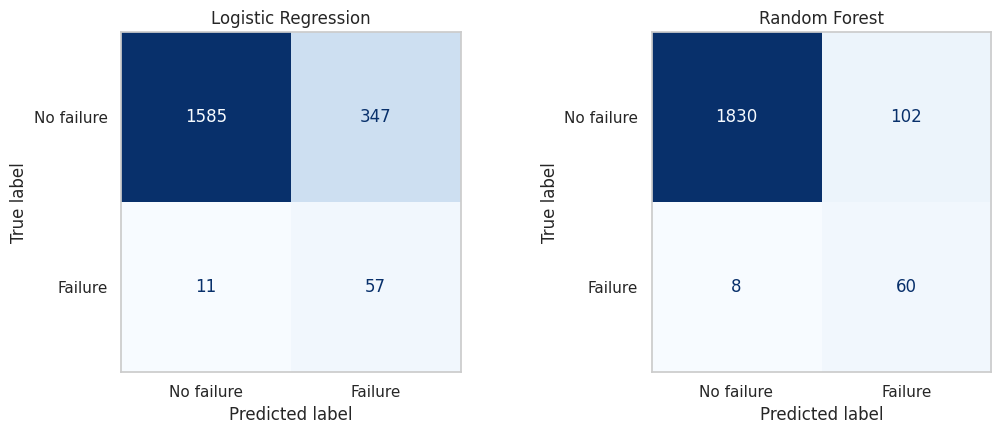

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, [("Logistic Regression", log_reg), ("Random Forest", rand_forest)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["No failure", "Failure"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name); ax.grid(False)
plt.tight_layout(); plt.show()

**How to read a confusion matrix** (rows = what really happened, columns = what the model predicted):

| | Predicted: No failure | Predicted: Failure |
|---|---|---|
| **Actually OK** | True Negative ✅ | False Positive ❌ (false alarm — unnecessary inspection) |
| **Actually failed** | False Negative ❌ (**missed failure — the costly one**) | True Positive ✅ (failure caught) |

In [10]:
tn, fp, fn, tp = confusion_matrix(y_test, rand_forest.predict(X_test)).ravel()
print(f"Random Forest on {len(y_test)} unseen machines:")
print(f"  Failures caught (TP)      : {tp}")
print(f"  Failures missed (FN)      : {fn}")
print(f"  False alarms (FP)         : {fp}")
print(f"  Correctly left alone (TN) : {tn}")

Random Forest on 2000 unseen machines:
  Failures caught (TP)      : 60
  Failures missed (FN)      : 8
  False alarms (FP)         : 102
  Correctly left alone (TN) : 1830


### What the results tell us
- **Random Forest is the better model here:** F1 ≈ 0.52 vs 0.24 for Logistic Regression. It catches 60 of the 68 real failures (recall 0.88) and misses 8.
- **The price is false alarms:** 102 healthy machines were flagged (63% of all alerts). Logistic Regression is much worse: 347 false alarms (86% of its alerts).
- **Why might Random Forest win?** Logistic Regression can only draw straight-line boundaries, while failures tend to happen at *extremes* (for example very high torque or very low speed) and in combinations of sensors. Trees can capture that.
- **Precision vs recall trade-off:** a missed failure usually costs far more than an extra inspection, so recall matters a lot. We can trade precision for recall (or the reverse) by changing the decision threshold, which I did not explore here.

## Step 7 — Which sensors matter most?

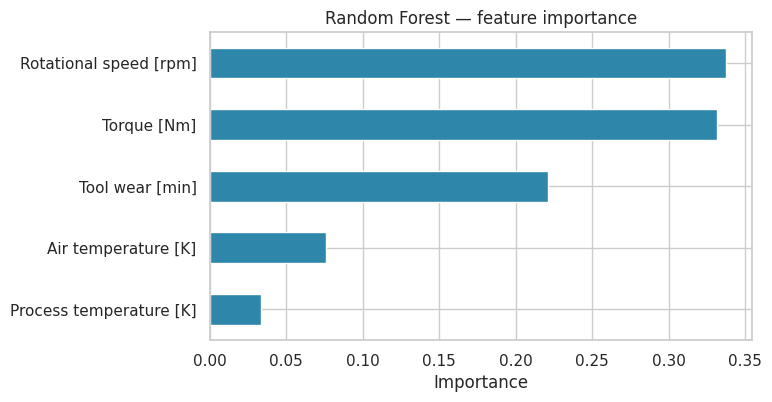

In [11]:
importance = pd.Series(rand_forest.feature_importances_, index=features).sort_values()
importance.plot(kind="barh", color="#2E86AB", figsize=(7, 4))
plt.title("Random Forest — feature importance"); plt.xlabel("Importance"); plt.show()

**Takeaway:** the most important inputs for the Random Forest are **Rotational speed**, **Torque** and **Tool wear**; the two temperatures matter much less. Note that rotation speed and torque are strongly (negatively) correlated with each other, so their importance is partly shared, and this built-in importance should be read as a rough guide, not an exact ranking. In a real plant, it hints at which sensors to monitor most closely.

## Step 8 — Use the model on new machines

In [12]:
new_machines = pd.DataFrame({
    "Air temperature [K]":      [298.1, 302.5, 300.0],
    "Process temperature [K]":  [308.6, 312.1, 310.0],
    "Rotational speed [rpm]":   [1500,  1550,  1480],
    "Torque [Nm]":             [40.0,  55.0,  45.0],
    "Tool wear [min]":          [150,   210,   180],
})
new_machines["failure_probability"] = rand_forest.predict_proba(new_machines[features])[:, 1].round(2)
new_machines["prediction"] = rand_forest.predict(new_machines[features])
new_machines

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],failure_probability,prediction
0,298.1,308.6,1500,40.0,150,0.02,0
1,302.5,312.1,1550,55.0,210,0.61,1
2,300.0,310.0,1480,45.0,180,0.04,0


## Limitations (honest summary)
- **Synthetic data:** AI4I 2020 is a synthetic teaching dataset with rule-based failures; real plant data would be harder.
- **Few failures:** the test set has only 68 failures, so the metrics could easily move by several points with a different split.
- **One split, one threshold:** I used a single 80/20 split and the default decision threshold (0.5), and did not tune the models.
- **Single snapshots:** each row is one machine at one moment; real predictive maintenance uses time-series history.

---
# 🎤 Interview Cheat Sheet

## 60-second pitch
> "I built a predictive-maintenance model that predicts whether a machine will fail from five sensor readings: air and process temperature, rotation speed, torque and tool wear. I used the public AI4I 2020 dataset — 10,000 machines, which is a synthetic dataset designed to mimic industrial data — and it is highly imbalanced: only about 3.4% of machines fail. I split the data 80/20 with stratification, trained Logistic Regression as a baseline and a Random Forest, and evaluated them on unseen data using accuracy, precision, recall, F1 and a confusion matrix. The Random Forest performed best, with an F1 of about 0.52: it caught 60 of the 68 failures in the test set but also raised 102 false alarms. Accuracy alone was misleading — a model that always says 'no failure' would score 97%, higher than either of my models — so I focused on recall and precision, because missing a real failure is much costlier than a false alarm."

## Likely questions & simple answers

**Why not just use accuracy?**
Only ~3.4% of machines fail. A model that always predicts "no failure" gets ~97% accuracy and catches nothing. In my results both models have *lower* accuracy than that baseline, but they catch most failures, so recall and precision tell the real story.

**Explain precision and recall in one line each.**
Precision: *of the machines I flagged, how many really failed?* Recall: *of the machines that really failed, how many did I flag?*

**What is a confusion matrix?**
A 2×2 table of correct and wrong predictions: true/false positives and true/false negatives. It shows *which kind* of mistake the model makes.

**Your precision is only 0.37. Is that acceptable?**
It means about 63% of alerts are false alarms (102 vs 60 real catches). Whether that is acceptable depends on costs: if a missed failure costs much more than an inspection, it can be. With more time I would tune the threshold and estimate the actual costs.

**Which matters more here — precision or recall?**
Usually recall, because a missed failure means unplanned downtime. But if inspections are very expensive, you want to balance both — that is what F1 does.

**Why did Random Forest beat Logistic Regression?**
Logistic Regression draws straight-line boundaries, and failures happen at extremes and in combinations of sensors (e.g. very high torque, very low speed). A forest of trees can capture that.

**Why split into train and test? What does `stratify` do?**
To check the model on data it has never seen; testing on training data would reward memorising. Stratify keeps the same failure percentage in both sets, which matters when failures are rare.

**What does `class_weight="balanced"` do?**
It makes mistakes on the rare failure class count more during training, so the model doesn't just ignore failures.

**Why scale the data for Logistic Regression but not Random Forest?**
Logistic Regression is sensitive to feature scales; trees split on thresholds, so scale doesn't matter to them.

**What is overfitting? Did you check?**
Overfitting is memorising the training data and doing worse on new data. I evaluated only on a held-out test set and limited the forest depth (`max_depth=6`).

**Is your test set big enough?**
Honestly, no: it has only 68 failures, so results are noisy. Cross-validation would give a more stable estimate; that is my first improvement.

**Where did the data come from?**
It's the public AI4I 2020 dataset from UCI. It is synthetic, designed to reflect real industrial data, so real-world performance would likely be lower.

**How would you improve it?**
Cross-validation, ROC-AUC/PR-AUC, threshold tuning with a cost assumption, features such as temperature difference and mechanical power (torque × speed), a statistical analysis before the modelling, and real time-series data.